# LIBRARY

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.stats import randint, uniform
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE

In [3]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [4]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100, stratify=y)

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Gradient Boosting

In [7]:
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6255217650566488
F1-score [0.77607241 0.2027833  0.08450704 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.85      0.78      1159
         1.0       0.27      0.16      0.20       314
         2.0       0.12      0.06      0.08       187
         3.0       0.00      0.00      0.00        17

    accuracy                           0.63      1677
   macro avg       0.28      0.27      0.27      1677
weighted avg       0.56      0.63      0.58      1677



In [8]:
clf = HistGradientBoostingClassifier(learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5813953488372093
F1-score [0.74519427 0.1754386  0.09302326 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.79      0.75      1159
         1.0       0.20      0.16      0.18       314
         2.0       0.12      0.07      0.09       187
         3.0       0.00      0.00      0.00        17

    accuracy                           0.58      1677
   macro avg       0.26      0.26      0.25      1677
weighted avg       0.54      0.58      0.56      1677



In [9]:
clf = LGBMClassifier(boosting_type='gbdt',  #'goss', #'dart'
                     max_depth=-1, # no limit
                     num_leaves=31,
                     n_estimators=100,
                     subsample_for_bin=200000,
                     objective='multiclass',
                     reg_alpha=0.0, #L1 regularization term on weights
                     reg_lambda=0.0, #L2 regularization term on weights
                     random_state=42
                   )
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3061
[LightGBM] [Info] Number of data points in the train set: 6705, number of used features: 17
[LightGBM] [Info] Start training from score -0.369217
[LightGBM] [Info] Start training from score -1.677313
[LightGBM] [Info] Start training from score -2.191870
[LightGBM] [Info] Start training from score -4.591101
Accuracy 0.6791890280262374
F1-score [0.81367144 0.12953368 0.06086957 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.96      0.81      1159
         1.0       0.35      0.08      0.13       314
         2.0       0.16      0.04      0.06       187
         3.0       0.00      0.00      0.00        17

    accuracy                           0.68      1677
   macro avg       0.30

c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
clf = CatBoostClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Learning rate set to 0.087191
0:	learn: 1.2912831	total: 205ms	remaining: 3m 24s
1:	learn: 1.2196042	total: 219ms	remaining: 1m 49s
2:	learn: 1.1607843	total: 232ms	remaining: 1m 17s
3:	learn: 1.1127843	total: 243ms	remaining: 1m
4:	learn: 1.0721479	total: 255ms	remaining: 50.8s
5:	learn: 1.0383837	total: 267ms	remaining: 44.3s
6:	learn: 1.0098202	total: 278ms	remaining: 39.4s
7:	learn: 0.9854639	total: 288ms	remaining: 35.8s
8:	learn: 0.9646144	total: 302ms	remaining: 33.2s
9:	learn: 0.9461827	total: 315ms	remaining: 31.1s
10:	learn: 0.9304440	total: 325ms	remaining: 29.3s
11:	learn: 0.9157128	total: 337ms	remaining: 27.8s
12:	learn: 0.9030940	total: 349ms	remaining: 26.5s
13:	learn: 0.8917358	total: 361ms	remaining: 25.4s
14:	learn: 0.8817681	total: 373ms	remaining: 24.5s
15:	learn: 0.8729561	total: 385ms	remaining: 23.7s
16:	learn: 0.8650806	total: 397ms	remaining: 22.9s
17:	learn: 0.8578500	total: 409ms	remaining: 22.3s
18:	learn: 0.8515171	total: 428ms	remaining: 22.1s
19:	learn: 

c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
clf = XGBClassifier(objective='binary:logistic', 
                    max_depth = 6,
                    learning_rate = 1.0,
                    gamma = 0.0,
                    reg_lambda = 1,
                    tree_method='exact', # 'approx'
                    use_label_encoder=False,
                    random_state=42
                   )

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

c:\Users\ESTER\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:10:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy 0.6571258199165176
F1-score [0.79877348 0.17943107 0.13333333 0.11111111]
              precision    recall  f1-score   support

         0.0       0.72      0.90      0.80      1159
         1.0       0.29      0.13      0.18       314
         2.0       0.22      0.10      0.13       187
         3.0       1.00      0.06      0.11        17

    accuracy                           0.66      1677
   macro avg       0.56      0.30      0.31      1677
weighted avg       0.58      0.66      0.60      1677



In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

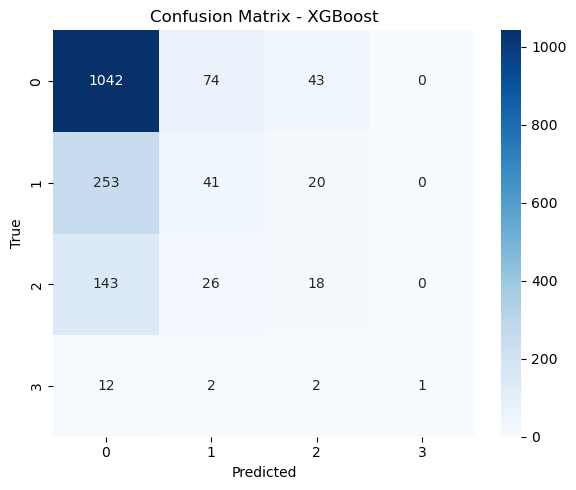

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()


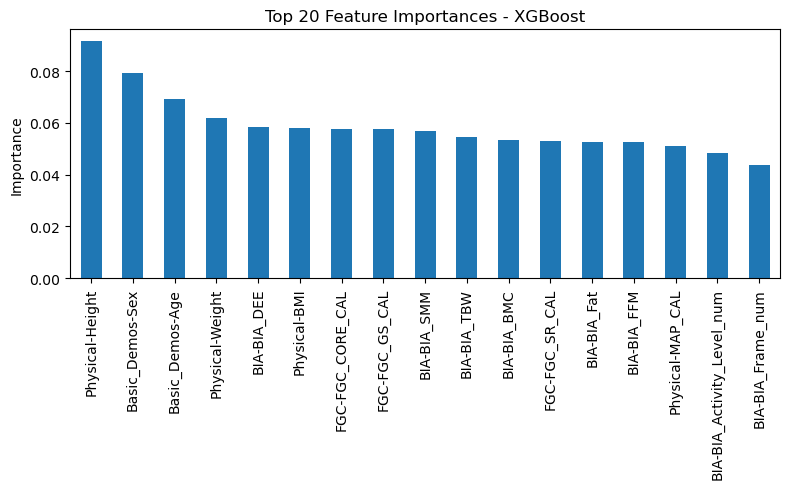

In [14]:
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=attributes).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importances - XGBoost')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning - XGBoost

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


In [24]:

param_grid = {
    'max_depth': [3,4,5,6,7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 300, 500],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

grid = GridSearchCV(XGBClassifier(tree_method='hist'), param_grid, scoring='f1_macro', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_params_)


{'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}


In [27]:
# Merr parametrat më të mirë nga GridSearchCV
best_params_ = grid.best_params_

# Ndërto modelin final me parametrat optimalë
best_model = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='logloss',
    random_state=42,
    **best_params   # shumë e rëndësishme!
)

# Trajno modelin final
best_model.fit(X_train, y_train)

# Parashiko
y_pred_best = best_model.predict(X_test)

# Vlerëso performancën
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average=None))
print(classification_report(y_test, y_pred_best))


Accuracy: 0.6648777579010137
F1-score: [0.80748663 0.18344519 0.11808118 0.11111111]
              precision    recall  f1-score   support

         0.0       0.72      0.91      0.81      1159
         1.0       0.31      0.13      0.18       314
         2.0       0.19      0.09      0.12       187
         3.0       1.00      0.06      0.11        17

    accuracy                           0.66      1677
   macro avg       0.56      0.30      0.31      1677
weighted avg       0.59      0.66      0.61      1677



In [21]:
clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "n_estimators": randint(100, 600),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0, 5)
}

random_search = RandomizedSearchCV(
    clf, param_dist, n_iter=60, scoring='f1_macro',
    cv=3, random_state=42, n_jobs=-1, verbose=2
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)


Fitting 3 folds for each of 60 candidates, totalling 180 fits
{'colsample_bytree': 0.981565812704725, 'gamma': 0.0038938292050716417, 'learning_rate': 0.30766346778736525, 'max_depth': 3, 'n_estimators': 559, 'reg_lambda': 3.0582658024414044, 'subsample': 0.7021198915659151}


In [22]:
best_params = random_search.best_params_
print(best_params)

{'colsample_bytree': 0.981565812704725, 'gamma': 0.0038938292050716417, 'learning_rate': 0.30766346778736525, 'max_depth': 3, 'n_estimators': 559, 'reg_lambda': 3.0582658024414044, 'subsample': 0.7021198915659151}


In [ ]:
best_params = random_search.best_params_

best_model = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='logloss',
    random_state=42,
    **best_params)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average=None))
print(classification_report(y_test, y_pred_best))


Accuracy: 0.6648777579010137
F1-score: [0.80748663 0.18344519 0.11808118 0.11111111]
              precision    recall  f1-score   support

         0.0       0.72      0.91      0.81      1159
         1.0       0.31      0.13      0.18       314
         2.0       0.19      0.09      0.12       187
         3.0       1.00      0.06      0.11        17

    accuracy                           0.66      1677
   macro avg       0.56      0.30      0.31      1677
weighted avg       0.59      0.66      0.61      1677



# Cascade Model

## model

In [ ]:
def train_one_step_xgb(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=30, n_splits=5, random_state=0):


    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

   
    param_dist = {
        "max_depth": randint(3, 10),
        "learning_rate": uniform(0.01, 0.3),
        "n_estimators": randint(100, 600),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3),
        "gamma": uniform(0, 5),
        'class_weight': ['balanced'],
        "reg_lambda": uniform(0, 5)}

    clf = XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='logloss',
        random_state=random_state)

   
    random_search = RandomizedSearchCV(
        clf,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='f1_macro',
        cv=n_splits,
        random_state=random_state,
        n_jobs=-1,
        verbose=2)

    random_search.fit(X_train, y_binary)
    best_model = random_search.best_estimator_

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")


    y_pred_binary = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')

    print(f"  Test F1     : {test_f1:.4f}")

    cm = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'not {step_name}', step_name])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.show()

    print(classification_report(y_test_binary, y_pred_binary,
                        target_names=[f'not {step_name}', step_name]))

    return best_model, y_pred_binary, y_proba

In [45]:
def print_dist(y, title='', binary=False):

    print(f"\n--- {title} ---")
    counts = Counter(y)

    if binary:
        print(f"0 → {counts.get(0, 0)} samples")
        print(f"1 → {counts.get(1, 0)} samples")
    else:
        for cls in sorted(counts.keys()):
            print(f"Class {cls}: {counts[cls]} samples")

    print(f"Total: {len(y)} samples")


In [46]:
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 6705
Test samples   : 1677


In [47]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


--- TRAIN ---
Class 0.0: 4635 samples
Class 1.0: 1253 samples
Class 2.0: 749 samples
Class 3.0: 68 samples
Total: 6705 samples

--- TEST ---
Class 0.0: 1159 samples
Class 1.0: 314 samples
Class 2.0: 187 samples
Class 3.0: 17 samples
Total: 1677 samples


## Class 0


In [48]:
# STEP 1: sii=0 vs [1, 2, 3] 
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [49]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 2070 samples
1 → 4635 samples
Total: 6705 samples

--- TEST  — binary step 1 ---
0 → 518 samples
1 → 1159 samples
Total: 1677 samples


In [ ]:


over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4635, 0: 3500})


In [51]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 3500 samples
1 → 4635 samples
Total: 8135 samples

--- TEST  — binary step 1 ---
0 → 518 samples
1 → 1159 samples
Total: 1677 samples



  STEP: sii=0
  Training samples : 8135
  Positive class   : 4635 samples
  Negative class   : 3500 samples
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\ESTER\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:38:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)



  Best params : {'class_weight': 'balanced', 'colsample_bytree': 0.8343778515612189, 'gamma': 0.4978454455540554, 'learning_rate': 0.11569349836015991, 'max_depth': 9, 'n_estimators': 591, 'reg_lambda': 4.205700648927998, 'subsample': 0.9713943232628539}
  Best CV F1  : 0.7121
  Test F1     : 0.6646


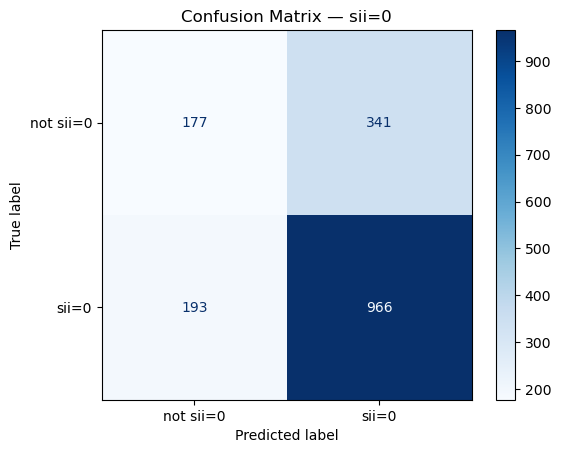

              precision    recall  f1-score   support

           0       0.48      0.34      0.40       518
           1       0.74      0.83      0.78      1159

    accuracy                           0.68      1677
   macro avg       0.61      0.59      0.59      1677
weighted avg       0.66      0.68      0.66      1677



In [62]:
model0, _, _ = train_one_step_xgb(X_res, y_res, X_te, y_binary_te, step_name='sii=0')
models[0] = model0

In [63]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te = models[0].predict(X_test)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_test.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1307 samples


## Class 1

In [64]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te   = X_te[mask_te],   y_te[mask_te]
original_idx = original_idx[mask_te]           # ← shrink index tracker too

In [65]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 2070
  Remaining test  : 711

--- TRAIN after step 1 ---
Class 1.0: 1253 samples
Class 2.0: 749 samples
Class 3.0: 68 samples
Total: 2070 samples

--- TEST  after step 1 ---
Class 0.0: 193 samples
Class 1.0: 314 samples
Class 2.0: 187 samples
Class 3.0: 17 samples
Total: 711 samples


In [66]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [67]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 817 samples
1 → 1253 samples
Total: 2070 samples

--- TEST  — binary step 2 ---
0 → 397 samples
1 → 314 samples
Total: 711 samples


In [ ]:

over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1253, 0: 900})


In [69]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 900 samples
1 → 1253 samples
Total: 2153 samples

--- TEST  — binary step 2 ---
0 → 397 samples
1 → 314 samples
Total: 711 samples



  STEP: sii=1
  Training samples : 2153
  Positive class   : 1253 samples
  Negative class   : 900 samples
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\ESTER\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:56:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)



  Best params : {'class_weight': 'balanced', 'colsample_bytree': 0.8343778515612189, 'gamma': 0.4978454455540554, 'learning_rate': 0.11569349836015991, 'max_depth': 9, 'n_estimators': 591, 'reg_lambda': 4.205700648927998, 'subsample': 0.9713943232628539}
  Best CV F1  : 0.5873
  Test F1     : 0.5126


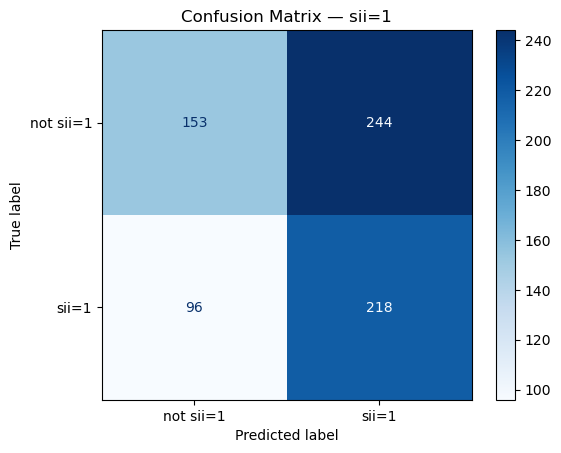

              precision    recall  f1-score   support

           0       0.61      0.39      0.47       397
           1       0.47      0.69      0.56       314

    accuracy                           0.52       711
   macro avg       0.54      0.54      0.52       711
weighted avg       0.55      0.52      0.51       711



In [ ]:
model1, _, _ = train_one_step_xgb(X_res, y_res, X_te, y_binary_te, step_name='sii=1')
models[1] = model1

In [73]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 462 samples


## Class 2

In [74]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [75]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 817
  Remaining test  : 493

--- TRAIN after step 2 ---
Class 2.0: 749 samples
Class 3.0: 68 samples
Total: 817 samples

--- TEST  after step 2 ---
Class 0.0: 193 samples
Class 1.0: 96 samples
Class 2.0: 187 samples
Class 3.0: 17 samples
Total: 493 samples


In [76]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [77]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 68 samples
1 → 749 samples
Total: 817 samples

--- TEST  — binary step 3 ---
0 → 306 samples
1 → 187 samples
Total: 493 samples


In [ ]:

over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 749, 0: 500})


In [79]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 500 samples
1 → 749 samples
Total: 1249 samples

--- TEST  — binary step 3 ---
0 → 306 samples
1 → 187 samples
Total: 493 samples



  STEP: sii=2
  Training samples : 1249
  Positive class   : 749 samples
  Negative class   : 500 samples
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\ESTER\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:56:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)



  Best params : {'class_weight': 'balanced', 'colsample_bytree': 0.7419917756479605, 'gamma': 0.16611192633088634, 'learning_rate': 0.30477248794755807, 'max_depth': 6, 'n_estimators': 402, 'reg_lambda': 3.61027799735174, 'subsample': 0.9599146977785886}
  Best CV F1  : 0.9343
  Test F1     : 0.2394


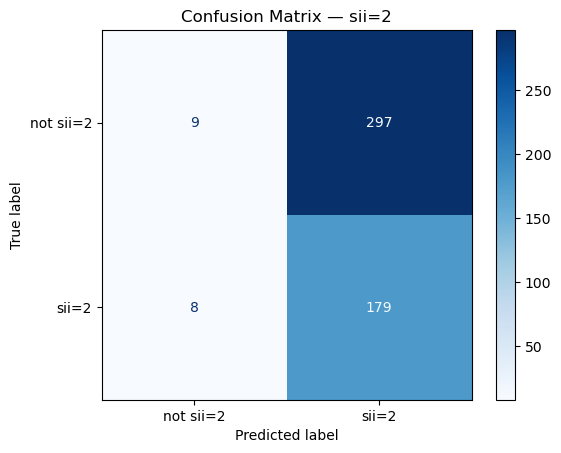

              precision    recall  f1-score   support

           0       0.53      0.03      0.06       306
           1       0.38      0.96      0.54       187

    accuracy                           0.38       493
   macro avg       0.45      0.49      0.30       493
weighted avg       0.47      0.38      0.24       493



In [81]:
model2, _, _ = train_one_step_xgb(X_res, y_res, X_te, y_binary_te, step_name='sii=2')
models[2] = model2


In [82]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 476 samples


## Class 3

In [83]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 68
  Remaining test  : 314


In [84]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 314 samples (all remaining)


## Final Result

In [85]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive  TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       1677        1159 966 341 193     0.7391  0.8335 0.7835
   sii=1 vs [2,3]        711         314 218 244  96     0.4719  0.6943 0.5619
     sii=2 vs [3]        493         187 179 297   8     0.3761  0.9572 0.5400
sii=3 (remaining)        314          17  17 297   0     0.0541  1.0000 0.1027


In [86]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.83      0.91      1159
       sii=1       1.00      0.69      0.82       314
       sii=2       1.00      0.96      0.98       187
       sii=3       0.05      1.00      0.10        17

    accuracy                           0.82      1677
   macro avg       0.76      0.87      0.70      1677
weighted avg       0.99      0.82      0.89      1677



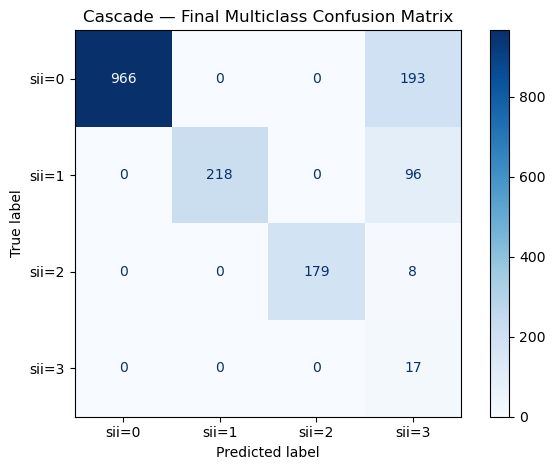

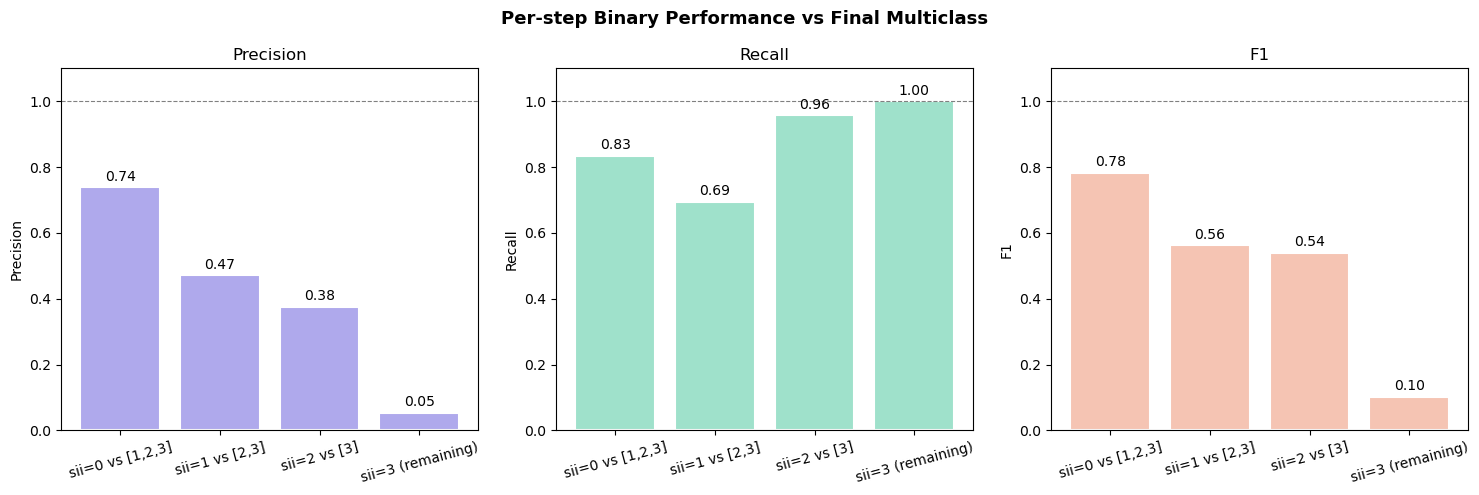

In [87]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1186
  sii=1 → true: 470    predicted: 348
  sii=2 → true: 281    predicted: 273
  sii=3 → true: 26     predicted: 708


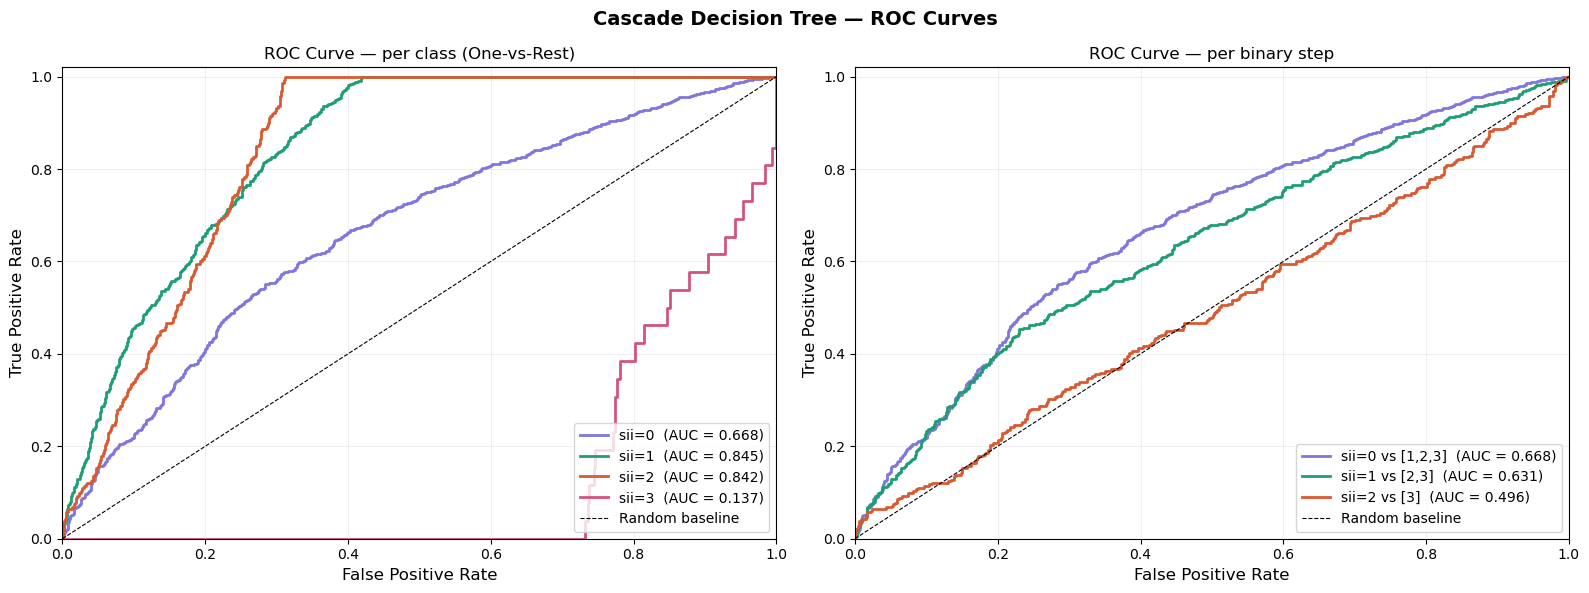


  AUC SUMMARY
  sii=0    → AUC = 0.6684
  sii=1    → AUC = 0.8451
  sii=2    → AUC = 0.8419
  sii=3    → AUC = 0.1372

  Macro AUC    : 0.6232
  Weighted AUC : 0.7153


In [ ]:
# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)